Loading Artifacts 

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL PURPOSE: Import SHAP and load all saved artifacts from Phase 4.
#
# WHY we load artifacts instead of retraining:
#   This is how a real workflow operates — train once, explain many times.
#   The notebook should be runnable without re-running Phase 4.
#   It also proves our joblib artifacts are complete and self-contained.
# ─────────────────────────────────────────────────────────────────────────────

import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from src.features import build_preprocessing_pipeline, get_feature_names
from src.explain import (
    build_explainer,
    compute_shap_values,
    get_risk_factors,
    build_explanation_narrative
)

# ── Visual style ─────────────────────────────────────────────────────────────
plt.rcParams.update({
    'axes.facecolor': '#F8F9FA', 'figure.facecolor': 'white',
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.4,
    'axes.titlesize': 12, 'axes.titleweight': 'bold'
})
FRAUD_CLR = '#E91E63'; LEGIT_CLR = '#2196F3'

# ── Load artifacts ────────────────────────────────────────────────────────────
model         = joblib.load('../models/xgboost_best.joblib')
pipeline      = joblib.load('../models/preprocessing_pipeline.joblib')
feature_names = joblib.load('../models/feature_names.joblib')
config        = joblib.load('../models/model_config.joblib')
THRESHOLD     = config['best_threshold']

# ── Rebuild test set (same split as Phase 4) ─────────────────────────────────
# WHY rebuild instead of saving X_test:
#   Saving the full test matrix as .npy is fine, but rebuilding from
#   the original data + same random_state=42 guarantees reproducibility
#   even if the .npy file is deleted. Both approaches are valid.
df        = pd.read_csv('../data/Fraud_Detection_Dataset_augmented.csv')
X         = df.drop(columns=['Fraudulent'])
y         = df['Fraudulent']
_, X_test, _, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)
X_test_proc = pipeline.transform(X_test)
X_test      = X_test.reset_index(drop=True)

print(f'Model loaded     : {config["model_name"]} ({config["imbalance_strategy"]})')
print(f'PR-AUC           : {config["pr_auc"]}')
print(f'Threshold        : {THRESHOLD}')
print(f'Test set shape   : {X_test_proc.shape}')
print(f'Features         : {len(feature_names)}')

c:\Users\aashi\Desktop\Fraud Detection System\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model loaded     : XGBoost (SMOTE)
PR-AUC           : 0.4595
Threshold        : 0.25
Test set shape   : (10024, 32)
Features         : 32


In [4]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL PURPOSE: Build the SHAP explainer and compute SHAP values for the
# entire test set. This is the foundational computation for all plots below.
#
# WHY compute for the full test set (not just a sample):
#   Global explainability plots (summary, dependence) require the full
#   distribution of SHAP values across many transactions to be meaningful.
#   A sample might miss important patterns in the tails.
#
# Runtime: ~5-15 seconds for 10,000 transactions with XGBoost.
# For much larger datasets, subsample to 5,000-10,000 for exploration.
# ─────────────────────────────────────────────────────────────────────────────

# Build explainer using our src/explain.py module
explainer   = build_explainer(model)
shap_values = compute_shap_values(explainer, X_test_proc)

# y_prob needed for identifying representative transactions
y_prob = model.predict_proba(X_test_proc)[:, 1]

print(f'SHAP values shape  : {shap_values.shape}')
print(f'Base value (E[f(x)]): {explainer.expected_value:.6f}')
print(f'\nWhat the base value means:')
print(f'  If we know NOTHING about a transaction, the model predicts')
print(f'  fraud probability = {explainer.expected_value:.4f}')
print(f'  Every SHAP value shows how each feature SHIFTS this prediction.')
print(f'\nVerification — SHAP sum should equal model output:')
shap_sum = shap_values[0].sum() + explainer.expected_value
# Note: for XGBoost the SHAP values are in log-odds space
print(f'  SHAP sum (idx 0) = {shap_values[0].sum() + explainer.expected_value:.6f}')
print(f'  Raw model output = {model.predict(X_test_proc[0:1], output_margin=True)[0]:.6f}')

SHAP values shape  : (10024, 32)
Base value (E[f(x)]): 0.020546

What the base value means:
  If we know NOTHING about a transaction, the model predicts
  fraud probability = 0.0205
  Every SHAP value shows how each feature SHIFTS this prediction.

Verification — SHAP sum should equal model output:
  SHAP sum (idx 0) = -3.328473
  Raw model output = -3.328471


Global Explainability - Feature importance 

Global Feature Importance — Mean |SHAP Value|
───────────────────────────────────────────────────────
   1. Previous_Fraudulent_Transactions              1.0153  ██████████████████████████████
   2. Number_of_Transactions_Last_24H               0.5389  ████████████████
   3. Time_of_Transaction                           0.3758  ███████████
   4. Account_Age                                   0.2023  ██████
   5. log_amount                                    0.1355  ████
   6. Transaction_Type_Online Purchase              0.1326  ███
   7. velocity_risk_very_high                       0.0822  ██
   8. Device_Used_Mobile                            0.0809  ██
   9. Device_Used_Tablet                            0.0728  ██
  10. time_of_day_morning                           0.0626  █
  11. Payment_Method_Debit Card                     0.0618  █
  12. Payment_Method_UPI                            0.0611  █
  13. Payment_Method_Net Banking                    0.0522  █
  14. Transaction_Type_Bi

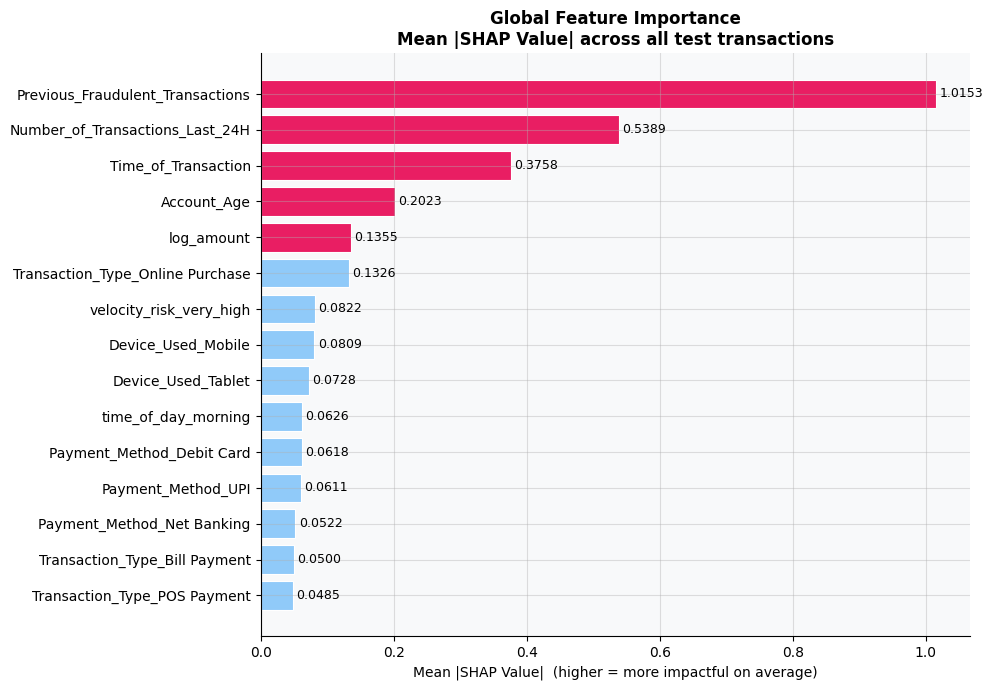


Top 3 most impactful features:
  1. Previous_Fraudulent_Transactions
  2. Number_of_Transactions_Last_24H
  3. Time_of_Transaction


In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL PURPOSE: Compute mean |SHAP| per feature and visualise.
#
# WHY mean ABSOLUTE SHAP (not mean SHAP):
#   A feature that pushes predictions +0.5 for half the transactions and
#   -0.5 for the other half would average to 0 mean SHAP — but it's
#   clearly a very important feature. Mean absolute SHAP captures
#   average MAGNITUDE regardless of direction.
# ─────────────────────────────────────────────────────────────────────────────

mean_abs_shap = np.abs(shap_values).mean(axis=0)

importance_df = pd.DataFrame({
    'Feature'    : feature_names,
    'Mean |SHAP|': mean_abs_shap
}).sort_values('Mean |SHAP|', ascending=False).reset_index(drop=True)

print('Global Feature Importance — Mean |SHAP Value|')
print('─' * 55)
for i, row in importance_df.head(15).iterrows():
    bar = '█' * int(row['Mean |SHAP|'] * 30)
    print(f'  {i+1:>2}. {row["Feature"]:<45} {row["Mean |SHAP|"]:.4f}  {bar}')

# Visualise
top15 = importance_df.head(15)
colors = [FRAUD_CLR if i < 5 else '#90CAF9' for i in range(len(top15))]

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top15['Feature'][::-1], top15['Mean |SHAP|'][::-1],
               color=colors[::-1], edgecolor='white', linewidth=0.8)
for bar, val in zip(bars, top15['Mean |SHAP|'][::-1]):
    ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title('Global Feature Importance\nMean |SHAP Value| across all test transactions',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Mean |SHAP Value|  (higher = more impactful on average)')
plt.tight_layout()
plt.show()

top3 = importance_df['Feature'].head(3).tolist()
print(f'\nTop 3 most impactful features:')
for i, f in enumerate(top3, 1):
    print(f'  {i}. {f}')

Global Explainability - SHAP Sumary Plot

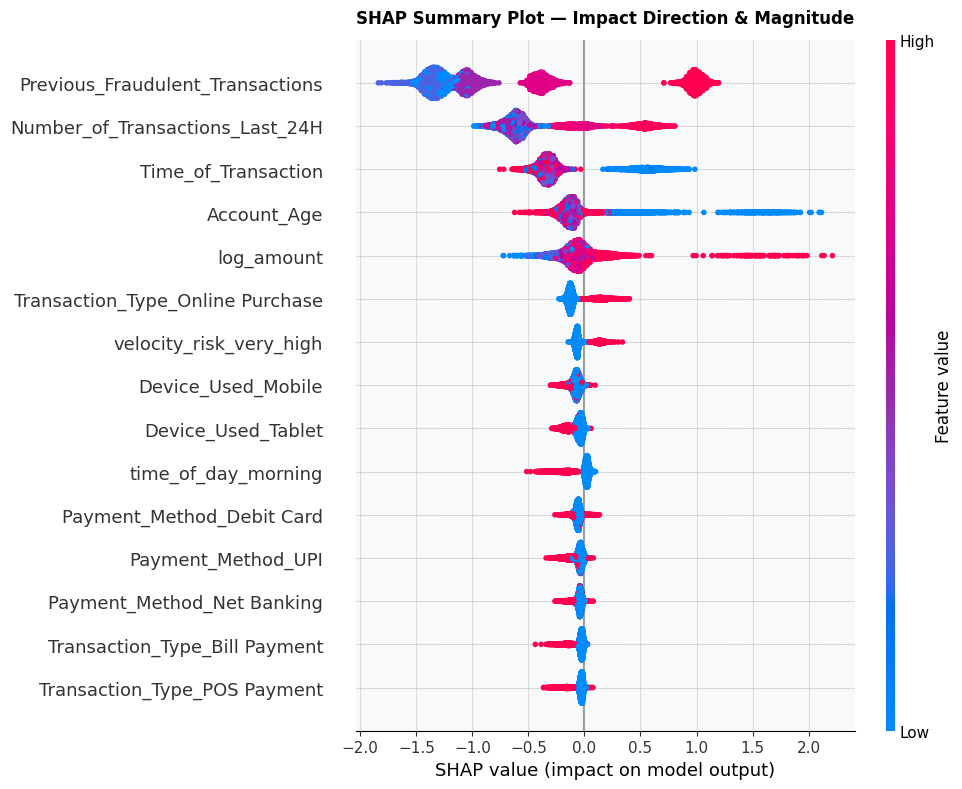


How to read this chart:
  • Each dot = one transaction in the test set
  • X position = SHAP value (positive → increases fraud risk)
  • Dot colour = actual feature value (red=high, blue=low)
  • Vertical spread = many transactions overlap at similar SHAP values

Key insights:
  ✦ Previous_Fraudulent_Transactions: red dots (high values) push RIGHT → prior fraud = higher risk ✅
  ✦ Account_Age: blue dots (low=young account) push RIGHT → new accounts = higher risk ✅
  ✦ log_amount: red dots (high amounts) push RIGHT → large transactions = higher risk ✅
  ✦ Number_of_Transactions_Last_24H: mixed spread → both extremes matter
  All top features behave as expected from domain knowledge — the model is
  learning real signal, not noise.



In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL PURPOSE: SHAP beeswarm summary plot — the most information-dense
# chart in the entire explainability toolkit.
#
# How to read this chart:
#   Take 'Previous_Fraudulent_Transactions' (top feature):
#   - Red dots (high values) are spread to the RIGHT → high prior fraud count
#     increases fraud probability. Makes domain sense.
#   - Blue dots (low values) cluster to the LEFT → few prior frauds
#     decreases fraud probability.
#
# WHY this is more useful than a correlation table:
#   It shows the FULL distribution of effects — not just the average.
#   Some features might have high impact for a small subset of transactions
#   but low average impact, which a correlation table would miss.
# ─────────────────────────────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(
    shap_values,
    X_test_proc,
    feature_names = feature_names,
    max_display   = 15,
    show          = False,
    plot_size     = None
)
plt.title('SHAP Summary Plot — Impact Direction & Magnitude',
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("""
How to read this chart:
  • Each dot = one transaction in the test set
  • X position = SHAP value (positive → increases fraud risk)
  • Dot colour = actual feature value (red=high, blue=low)
  • Vertical spread = many transactions overlap at similar SHAP values

Key insights:
  ✦ Previous_Fraudulent_Transactions: red dots (high values) push RIGHT → prior fraud = higher risk ✅
  ✦ Account_Age: blue dots (low=young account) push RIGHT → new accounts = higher risk ✅
  ✦ log_amount: red dots (high amounts) push RIGHT → large transactions = higher risk ✅
  ✦ Number_of_Transactions_Last_24H: mixed spread → both extremes matter
  All top features behave as expected from domain knowledge — the model is
  learning real signal, not noise.
""")

Global Explainability - Dependance Plots 

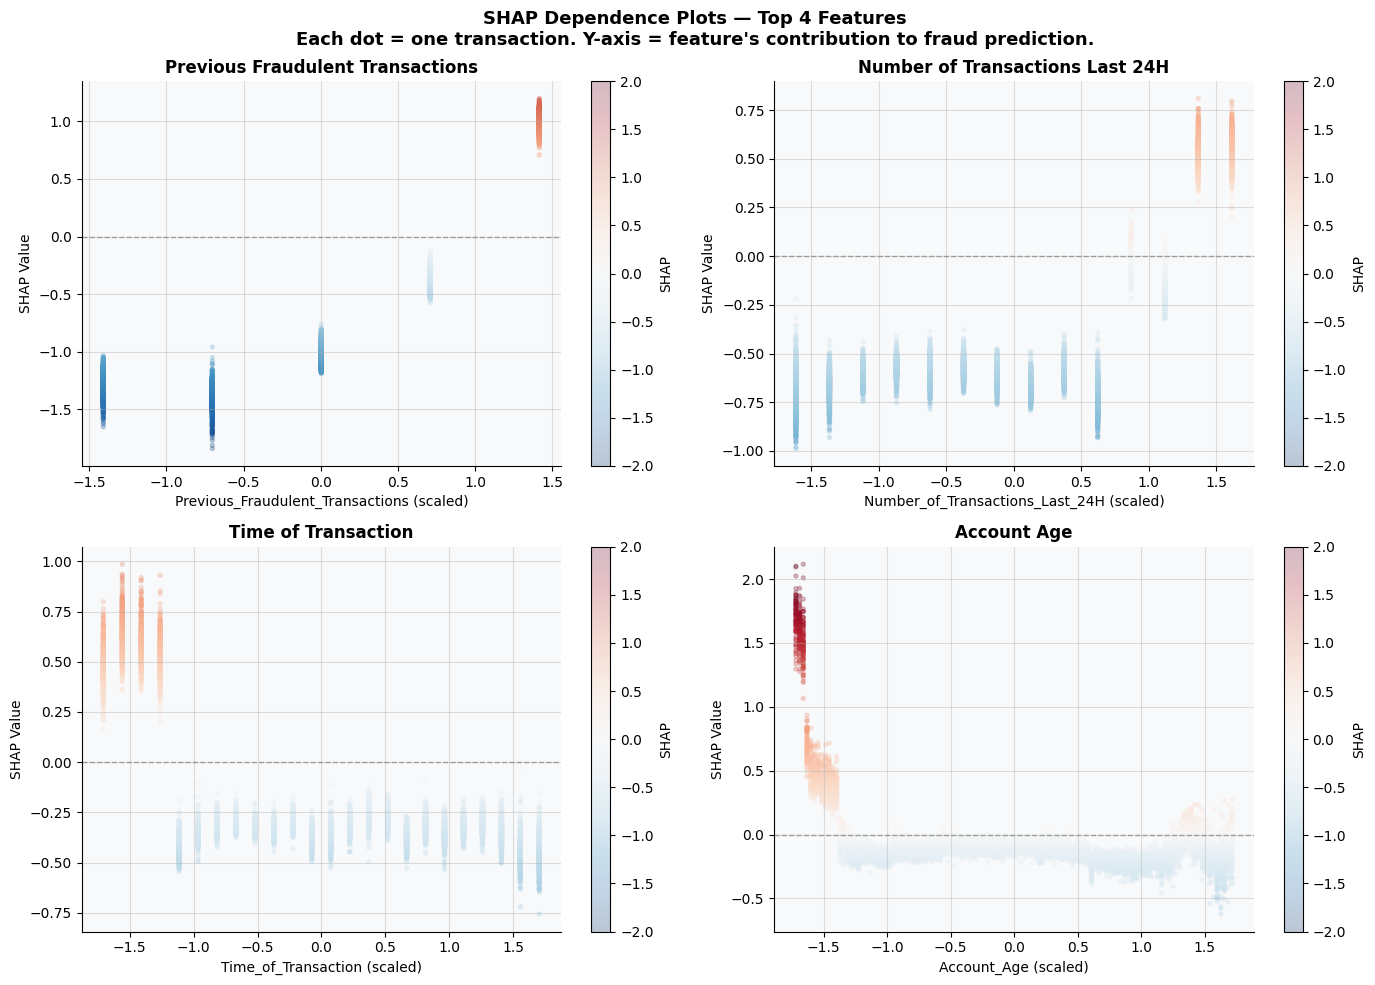


Reading the dependence plots:

  Previous_Fraudulent_Transactions:
    → Clear positive slope: more prior fraud = higher SHAP = higher fraud risk
    → This is the strongest single predictor in the model

  Number_of_Transactions_Last_24H:
    → U-shaped or positive slope at high end: very high velocity = elevated risk
    → Captures card testing / account draining behaviour

  Time_of_Transaction:
    → Variation across hours: late night hours show higher SHAP values
    → The model learned the night-time risk signal we expected from EDA

  Account_Age:
    → Negative slope at low values: young accounts (small, scaled values)
      have high SHAP → newer accounts = more suspicious
    → Classic fraud pattern: open account, commit fraud before controls kick in



In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL PURPOSE: Plot SHAP dependence for the top 4 most impactful features.
#
# WHY dependence plots matter:
#   They reveal the MODEL's learned relationship between a feature and
#   fraud risk — not the raw correlation in the data, but the actual
#   decision boundary the model has learned.
#
# Each dot is one transaction:
#   x-axis = raw feature value (scaled, so 0 = mean, 1 = +1 std)
#   y-axis = SHAP value for that feature for that transaction
#   colour = SHAP value (red=high fraud impact, blue=low)
#
# A flat line → feature has constant effect regardless of value
# An upward curve → higher feature value → more fraud risk
# A threshold/step → risk jumps at a specific value (ideal for rule extraction)
# ─────────────────────────────────────────────────────────────────────────────

top4_features = [
    'Previous_Fraudulent_Transactions',
    'Number_of_Transactions_Last_24H',
    'Time_of_Transaction',
    'Account_Age',
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
fig.suptitle('SHAP Dependence Plots — Top 4 Features\n'
             'Each dot = one transaction. Y-axis = feature\'s contribution to fraud prediction.',
             fontsize=13, fontweight='bold')

for i, feat in enumerate(top4_features):
    ax  = axes[i]
    idx = feature_names.index(feat)
    sc  = ax.scatter(
        X_test_proc[:, idx],
        shap_values[:, idx],
        c     = shap_values[:, idx],
        cmap  = 'RdBu_r',
        alpha = 0.25,
        s     = 8,
        vmin  = -2, vmax = 2
    )
    ax.axhline(0, color='gray', linestyle='--', linewidth=1, alpha=0.7)
    ax.set_xlabel(f'{feat} (scaled)', fontsize=10)
    ax.set_ylabel('SHAP Value', fontsize=10)
    ax.set_title(feat.replace('_', ' '))
    plt.colorbar(sc, ax=ax, label='SHAP')

plt.tight_layout()
plt.show()

print("""
Reading the dependence plots:

  Previous_Fraudulent_Transactions:
    → Clear positive slope: more prior fraud = higher SHAP = higher fraud risk
    → This is the strongest single predictor in the model

  Number_of_Transactions_Last_24H:
    → U-shaped or positive slope at high end: very high velocity = elevated risk
    → Captures card testing / account draining behaviour

  Time_of_Transaction:
    → Variation across hours: late night hours show higher SHAP values
    → The model learned the night-time risk signal we expected from EDA

  Account_Age:
    → Negative slope at low values: young accounts (small, scaled values)
      have high SHAP → newer accounts = more suspicious
    → Classic fraud pattern: open account, commit fraud before controls kick in
""")

Local Explainability - High Fraud Transaction 

Transaction index : 4292
Fraud probability : 0.9533
Actual label      : FRAUD ✅ (model is correct)
Decision          : 🚨 FRAUD ALERT

Raw transaction features:
Transaction_Amount                        49997.8
Transaction_Type                    Bank Transfer
Time_of_Transaction                           5.0
Device_Used                               Desktop
Previous_Fraudulent_Transactions                4
Account_Age                                     1
Number_of_Transactions_Last_24H                 3
Payment_Method                                UPI


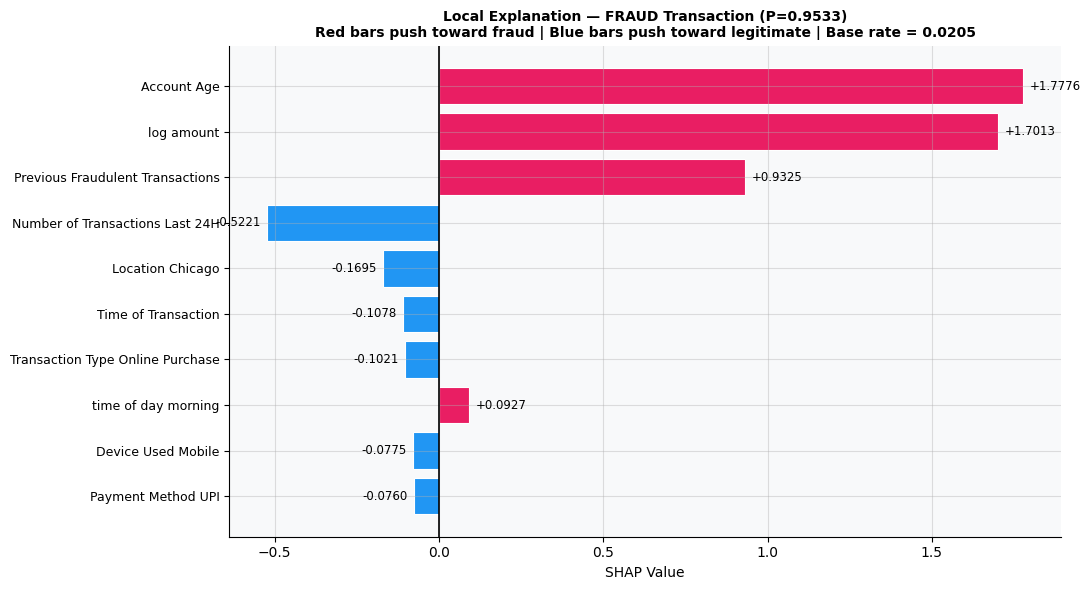

In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL PURPOSE: Explain the single transaction with the highest fraud probability
# among actual fraud cases in the test set.
#
# WHY pick the highest P(fraud) actual fraud:
#   This is the model's most confident correct fraud prediction — the clearest
#   example of how the model "thinks" when it detects fraud. It makes the
#   explanation most instructive.
# ─────────────────────────────────────────────────────────────────────────────

# Find the transaction — highest P(fraud) among actual fraud cases
fraud_indices    = np.where(y_test.values == 1)[0]
high_fraud_idx   = fraud_indices[np.argmax(y_prob[fraud_indices])]
prob_high        = y_prob[high_fraud_idx]
sv_high          = shap_values[high_fraud_idx]

print(f'Transaction index : {high_fraud_idx}')
print(f'Fraud probability : {prob_high:.4f}')
print(f'Actual label      : FRAUD ✅ (model is correct)')
print(f'Decision          : {"🚨 FRAUD ALERT" if prob_high >= THRESHOLD else "✅ APPROVED"}')
print()

# Show the raw transaction data
print('Raw transaction features:')
print(X_test.iloc[high_fraud_idx][[
    'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction',
    'Device_Used', 'Previous_Fraudulent_Transactions',
    'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method'
]].to_string())

# ── Waterfall chart ───────────────────────────────────────────────────────────
top_idx  = np.argsort(np.abs(sv_high))[-10:]
top_feat = [feature_names[i] for i in top_idx]
top_vals = sv_high[top_idx]

fig, ax = plt.subplots(figsize=(11, 6))
colors  = [FRAUD_CLR if v > 0 else LEGIT_CLR for v in top_vals]
ax.barh(range(len(top_vals)), top_vals, color=colors, edgecolor='white', linewidth=0.8)
ax.set_yticks(range(len(top_feat)))
ax.set_yticklabels([f.replace('_', ' ') for f in top_feat], fontsize=9)
ax.axvline(0, color='black', linewidth=1.2)
for j, (bar, val) in enumerate(zip(ax.patches, top_vals)):
    ax.text(val + (0.02 if val >= 0 else -0.02),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8.5)
ax.set_title(
    f'Local Explanation — FRAUD Transaction (P={prob_high:.4f})\n'
    f'Red bars push toward fraud | Blue bars push toward legitimate | '
    f'Base rate = {explainer.expected_value:.4f}',
    fontsize=10, fontweight='bold')
ax.set_xlabel('SHAP Value')
plt.tight_layout()
plt.show()

Local Explainability - Low Fraud Transaction 

Transaction index : 6977
Fraud probability : 0.0061
Actual label      : LEGITIMATE ✅ (model is correct)
Decision          : ✅ APPROVED

Raw transaction features:
Transaction_Amount                       474.75
Transaction_Type                    POS Payment
Time_of_Transaction                         6.0
Device_Used                              Mobile
Previous_Fraudulent_Transactions              0
Account_Age                                  25
Number_of_Transactions_Last_24H               2
Payment_Method                      Net Banking


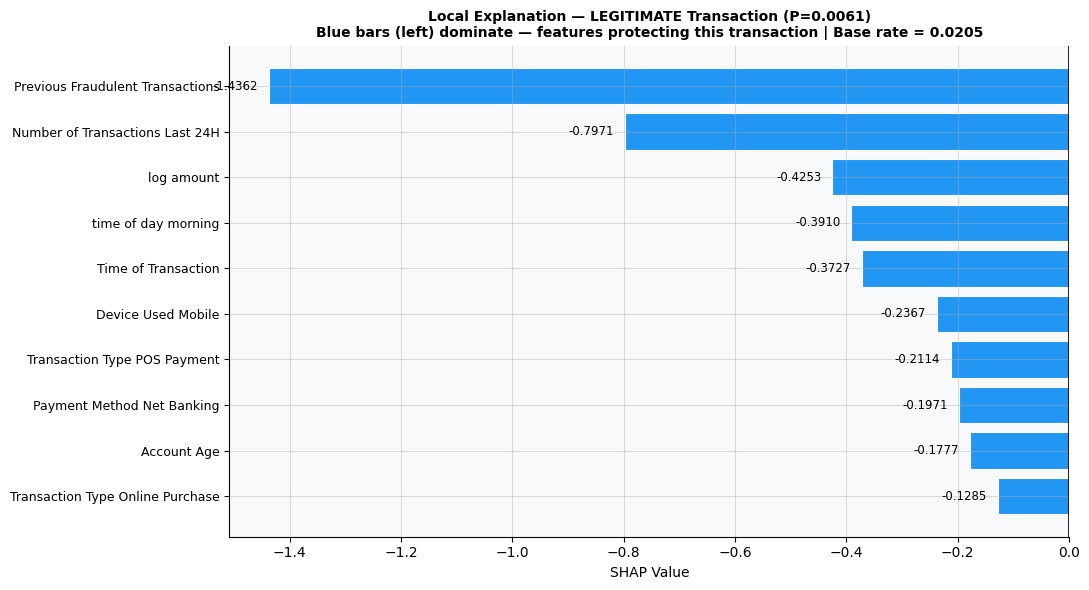

In [9]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL PURPOSE: Explain the single transaction with the LOWEST fraud probability
# among actual legitimate transactions.
#
# WHY compare the two extremes:
#   Showing both the clearest fraud and the clearest legitimate transaction
#   demonstrates that the model's reasoning is consistent and directionally
#   correct for both classes — not just for fraud.
#   In a real deployment, an analyst would check borderline cases (P≈0.30)
#   more carefully — but understanding the extremes builds the baseline.
# ─────────────────────────────────────────────────────────────────────────────

legit_indices  = np.where(y_test.values == 0)[0]
low_fraud_idx  = legit_indices[np.argmin(y_prob[legit_indices])]
prob_low       = y_prob[low_fraud_idx]
sv_low         = shap_values[low_fraud_idx]

print(f'Transaction index : {low_fraud_idx}')
print(f'Fraud probability : {prob_low:.4f}')
print(f'Actual label      : LEGITIMATE ✅ (model is correct)')
print(f'Decision          : {"🚨 FRAUD ALERT" if prob_low >= THRESHOLD else "✅ APPROVED"}')
print()
print('Raw transaction features:')
print(X_test.iloc[low_fraud_idx][[
    'Transaction_Amount', 'Transaction_Type', 'Time_of_Transaction',
    'Device_Used', 'Previous_Fraudulent_Transactions',
    'Account_Age', 'Number_of_Transactions_Last_24H', 'Payment_Method'
]].to_string())

top_idx2  = np.argsort(np.abs(sv_low))[-10:]
top_feat2 = [feature_names[i] for i in top_idx2]
top_vals2 = sv_low[top_idx2]

fig, ax = plt.subplots(figsize=(11, 6))
colors2 = [FRAUD_CLR if v > 0 else LEGIT_CLR for v in top_vals2]
ax.barh(range(len(top_vals2)), top_vals2, color=colors2, edgecolor='white', linewidth=0.8)
ax.set_yticks(range(len(top_feat2)))
ax.set_yticklabels([f.replace('_', ' ') for f in top_feat2], fontsize=9)
ax.axvline(0, color='black', linewidth=1.2)
for j, (bar, val) in enumerate(zip(ax.patches, top_vals2)):
    ax.text(val + (0.02 if val >= 0 else -0.02),
            bar.get_y() + bar.get_height()/2,
            f'{val:+.4f}', va='center',
            ha='left' if val >= 0 else 'right', fontsize=8.5)
ax.set_title(
    f'Local Explanation — LEGITIMATE Transaction (P={prob_low:.4f})\n'
    f'Blue bars (left) dominate — features protecting this transaction | '
    f'Base rate = {explainer.expected_value:.4f}',
    fontsize=10, fontweight='bold')
ax.set_xlabel('SHAP Value')
plt.tight_layout()
plt.show()

Business Narative Generator 

In [10]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL PURPOSE: Demonstrate the end-to-end explanation pipeline — from
# raw transaction to structured JSON output as the API would return it.
#
# WHY demonstrate this in the notebook:
#   The notebook is the integration test for src/explain.py.
#   Running this cell confirms the function works correctly before
#   we wire it into the FastAPI in Phase 6.
# ─────────────────────────────────────────────────────────────────────────────

import json

print('=' * 70)
print('EXAMPLE 1 — HIGH FRAUD TRANSACTION')
print('=' * 70)

explanation_fraud = build_explanation_narrative(
    fraud_probability = float(prob_high),
    shap_vals         = shap_values[high_fraud_idx],
    feature_names     = feature_names,
    threshold         = THRESHOLD,
    top_n             = 5
)
print(json.dumps(explanation_fraud, indent=2))

print('\n' + '=' * 70)
print('EXAMPLE 2 — LOW FRAUD (LEGITIMATE) TRANSACTION')
print('=' * 70)

explanation_legit = build_explanation_narrative(
    fraud_probability = float(prob_low),
    shap_vals         = shap_values[low_fraud_idx],
    feature_names     = feature_names,
    threshold         = THRESHOLD,
    top_n             = 5
)
print(json.dumps(explanation_legit, indent=2))

print("""
This is exactly what the API will return in Phase 6.
A fraud analyst receives:
  1. The decision (FRAUD / LEGITIMATE)
  2. The exact probability score
  3. The top risk factors with their impact magnitude and direction
  4. A one-sentence human-readable summary

This makes the model auditable, trustworthy, and compliant.
""")

EXAMPLE 1 — HIGH FRAUD TRANSACTION
{
  "decision": "FRAUD",
  "fraud_probability": 0.9533,
  "threshold": 0.25,
  "is_fraud": true,
  "top_risk_factors": [
    {
      "feature": "Account_Age",
      "label": "Account age",
      "shap_value": 1.7776,
      "direction": "increases_risk",
      "impact": "high"
    },
    {
      "feature": "log_amount",
      "label": "Transaction amount",
      "shap_value": 1.7013,
      "direction": "increases_risk",
      "impact": "high"
    },
    {
      "feature": "Previous_Fraudulent_Transactions",
      "label": "Prior fraud history",
      "shap_value": 0.9325,
      "direction": "increases_risk",
      "impact": "high"
    },
    {
      "feature": "Number_of_Transactions_Last_24H",
      "label": "Transaction velocity (24h)",
      "shap_value": -0.5221,
      "direction": "decreases_risk",
      "impact": "high"
    },
    {
      "feature": "Location_Chicago",
      "label": "Location Chicago",
      "shap_value": -0.1695,
      "directi

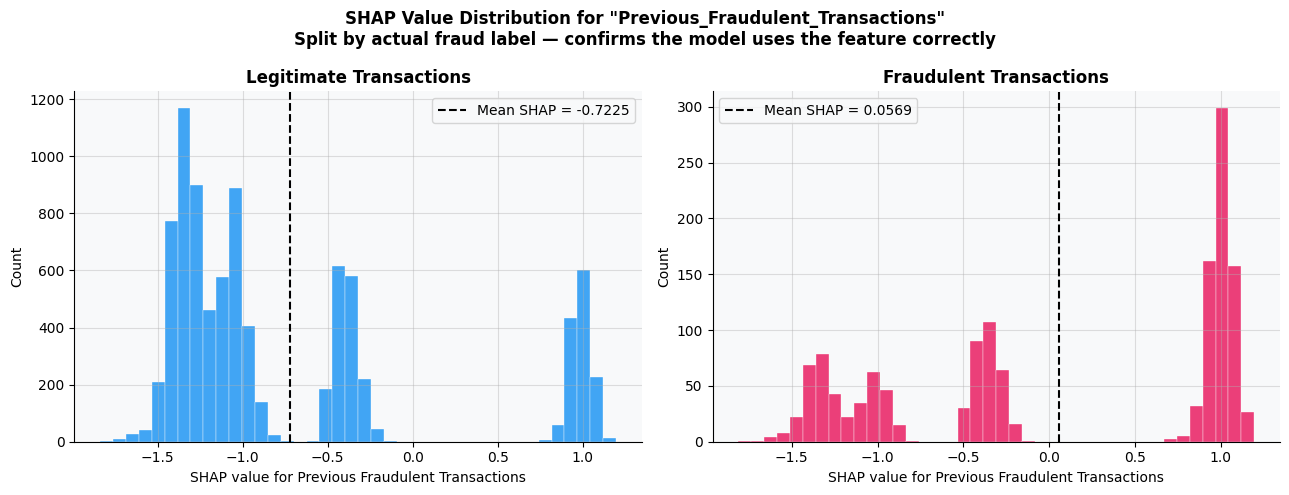

Mean SHAP for Previous_Fraudulent_Transactions:
  Legitimate transactions: -0.7225
  Fraudulent transactions: 0.0569
  Separation             : 0.7794

  ✅ Fraud transactions show higher SHAP → model uses feature correctly


In [11]:
# ─────────────────────────────────────────────────────────────────────────────
# CELL PURPOSE: SHAP value distribution split by actual label.
#
# This chart shows whether SHAP values for the top feature cleanly separate
# fraud from legitimate transactions — a final sanity check that the model
# is using the feature in the right direction.
# ─────────────────────────────────────────────────────────────────────────────

top_feat_name = importance_df['Feature'].iloc[0]  # top feature by mean |SHAP|
top_feat_idx  = feature_names.index(top_feat_name)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    f'SHAP Value Distribution for "{top_feat_name}"\n'
    f'Split by actual fraud label — confirms the model uses the feature correctly',
    fontsize=12, fontweight='bold')

for ax, label, color, title in [
    (axes[0], 0, LEGIT_CLR, 'Legitimate Transactions'),
    (axes[1], 1, FRAUD_CLR, 'Fraudulent Transactions')
]:
    mask = y_test.values == label
    sv   = shap_values[mask, top_feat_idx]
    ax.hist(sv, bins=40, color=color, edgecolor='white', linewidth=0.3, alpha=0.85)
    ax.axvline(sv.mean(), color='black', linestyle='--', linewidth=1.5,
               label=f'Mean SHAP = {sv.mean():.4f}')
    ax.set_title(title)
    ax.set_xlabel(f'SHAP value for {top_feat_name.replace("_", " ")}')
    ax.set_ylabel('Count')
    ax.legend()

plt.tight_layout()
plt.show()

sv_fraud = shap_values[y_test.values == 1, top_feat_idx]
sv_legit = shap_values[y_test.values == 0, top_feat_idx]
print(f'Mean SHAP for {top_feat_name}:')
print(f'  Legitimate transactions: {sv_legit.mean():.4f}')
print(f'  Fraudulent transactions: {sv_fraud.mean():.4f}')
print(f'  Separation             : {sv_fraud.mean() - sv_legit.mean():.4f}')
print(f'\n  ✅ Fraud transactions show higher SHAP → model uses feature correctly')